Скажу честно, я заколебался писать эти циклы просто чтобы узнать оптимальные гиперпараметры у тех или иных моделей. А их очень много. Собственно, если исключить ручной подбор, то мы имеем 3 способа решения сия проблемы:
1. GridSearchCV в sklearn. Тоже самое, что делать циклы, но только не надо прописывать для каждого гиперпараметра циклы. Всё будет также долго
2. RandomizedSearchCV в sklearn. Случайно подбирает гиперпараметры, что может дать(и часто даёт) неплохие гиперпараметры за очень быстрое время
3. Байесовская оптимизация. Это его величество Optuna, а ещё bayesian-optimization, Hyperopt. НО чаще всего используют именно Optuna

In [41]:
!pip install optuna

Использовать будем HistGradientBoosting в sklearn. Мейн отличие его от обычного градиентного бустинга состоит в том, что он имеет поддержку категориальных фичей из коробки, из-за чего one-hot encoding не нужен, а непрерывные фичи он разбивает на дискретные интервалы, что делает его быстрее. Подбирать будем все гиперпараметры, если у меня хватит смелости, потому что потому

In [53]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score#тут я постараюсь доказать что аккураси чаще всего дерьмо
import optuna#впервые юзаю оптуну относительно осознанно

In [54]:
df = pd.read_csv('../datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [55]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Как всегда, EDA я проводить не буду, у меня нет сил. Датасет: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
Просто всё закинем в модель и будем молиться


In [75]:
X = df.drop(columns=['customerID', 'Churn'])#Мне просто что-то подсказывает, что айди тут лишний, хотя про разбиение на трейн/тест надо поговорить
y = df['Churn']
#Надо объяснить нахера это. Короче, если мы просто всё попытаемся перевести в категориальные признаки, то мы пойдём куда подальше
#потому что max_bins у градиентного бустинга 255, а у того же TotalCharges в ошибке под 5к возможных комбинаций. Но TotalCharges число
#Поэтому, если это число, то пусть будет числом, а если нет, то мы ставим ему dtype category, чтобы поддержка категориальных фичей была
for col in X.select_dtypes(include='str').columns:
    X[col] = X[col].replace(r'^\s*$', np.nan, regex=True)
    try:
        X[col] = pd.to_numeric(X[col])
    except:
        X[col] = X[col].astype('category')
y = np.where(y == 'Yes', 1, 0)
model = HistGradientBoostingClassifier(categorical_features='from_dtype', max_bins=255)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)#стратифай поставил потому что неравное распределение классов

Официально, наш бейзлайн - модель с гиперпараметрами из коробки

In [76]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(accuracy, f1)

0.7915956842703009 0.565680473372781


Доказываю почему accuracy кал здесь по сравнению с f1. Доказать очень легко, посмотрим на распределение таргета

Text(0, 0.5, 'количество объектов')

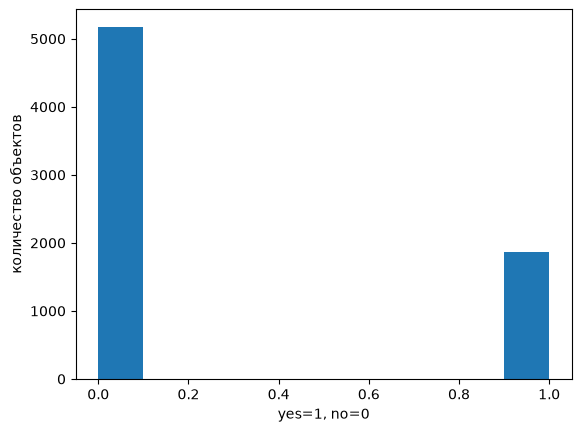

In [77]:
import matplotlib.pyplot as plt
plt.hist(y)
plt.xlabel("yes=1, no=0")
plt.ylabel('количество объектов')

Если до сих пор непонятно почему, то посмотрим на classification_report

In [78]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1294
           1       0.63      0.51      0.57       467

    accuracy                           0.79      1761
   macro avg       0.73      0.70      0.71      1761
weighted avg       0.78      0.79      0.78      1761



Тут очевидно, что 0 встречается в 3 раза чаще, чем 1, поэтому аккураси будет высоким у модели. А ф1 будет низким, если на втором классе она работает хуже, а по classification_report она действительно работает хуже. Тогда почему ф1 не 0.71, каким должен быть, а 0.57? Чёрт его знает.. 

на самом деле тут лучше использовать кросс-валидацию, нооо мне лень  

Время использовать подбор гиперпараметров! Я буду замерять время, classification_report, а после составлю табличку из вида подбора гиперпараметров, макро ф1 скора и времени. Начнём с GridSearchCV

In [79]:
import time

param_grid = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "max_iter": [50, 100, 200, 300],
    "max_leaf_nodes": [15, 31, 63],
    "max_depth": [None, 5, 10],
}
start = time.perf_counter()
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Parameters: ", grid_search.best_params_)
print("Best Train Score: ", grid_search.best_score_)
elapsed = time.perf_counter() - start
#мне очень лень писать код
print(grid_search.score(X_test, y_test))
print('time:', elapsed)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters:  {'learning_rate': 0.03, 'max_depth': 5, 'max_iter': 200, 'max_leaf_nodes': 15}
Best Train Score:  0.5855542252081298
0.5703794369645043
time: 80.41753940004855



(время считается в секундах если что)

In [82]:


random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)
start = time.perf_counter()

random_search.fit(X_train, y_train)

elapsed = time.perf_counter() - start

print("Best Parameters: ", random_search.best_params_)
print("Best Train Score: ", random_search.best_score_)
elapsed = time.perf_counter() - start

print(random_search.score(X_test, y_test))
print('time:', elapsed)

Best Parameters:  {'max_leaf_nodes': 15, 'max_iter': 50, 'max_depth': 5, 'learning_rate': 0.1}
Best Train Score:  0.5852590410270475
0.5676004872107187
time: 11.151635699905455


Кхм... Результаты несколько странные, а я немного отчаялся  
там есть ещё куча мелких нюансов, в виде например целевой метрики при оптимизации гиперпараметров, ноооо  

Время Optuna!~

Но для начала несколько слов про байесовскую оптимизацию. 
Если мы будем рассматривать модель машинного обучения как функцию от нескольких гиперпараметров, то обучать каждый раз, как в GridSearchCV, становится непозволительной роскошью как с точки зрения времени, так и с точки зрения вычислительных ресурсов. RandomSearchCV может просто пропустить более хорошие гиперпараметры, а байесовская оптимизация поможет избежать недоразумений. Очень важно понимать, что чаще всего нам важна не математическая оптимизация сама по себе, а минимизация временных и вычислительных ресурсов, минимизация дорогих вычислений функции  

Байесовская оптимизация пытается найти хорошие гиперпараметры, используя ограниченное количество итераций, причём при выборе следующей комбинации учитываются результаты предыдущих экспериментов.
Для этого строится так называемая surrogate model - модель-заменитель, которая пытается описать зависимость качества модели от выбранных гиперпараметров. После каждого эксперимента она обновляется с учётом нового результата.  

Затем специальная функция, называемая acquisition function, оценивает, какие гиперпараметры имеет смысл проверить следующими. При этом учитываются как уже найденные хорошие области, так и области, в которых мы пока мало экспериментировали. Таким образом, Bayesian Optimization пытается найти баланс между exploitation - исследованием уже перспективных комбинаций - и exploration - исследованием малоизученных областей.

Одним из инструментов, позволяющих применять подобный подход на практике, является Optuna. В Optuna выбор следующего набора гиперпараметров выполняется с помощью семплера. По умолчанию используется TPESampler, основанный на методе Tree-structured Parzen Estimator (TPE).

In [90]:
def objective(trial):
    max_depth = trial.suggest_int("max_depth", 2, 10)
    learning_rate = trial.suggest_float(
        "learning_rate", 0.01, 0.15, log=True
    )
    max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 10, 40)
    max_iter = trial.suggest_int('max_iter', 10, 500)
    

    model = HistGradientBoostingClassifier(
        max_depth=max_depth,
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_leaf_nodes=max_leaf_nodes,
        categorical_features="from_dtype",
        max_bins=255
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    return f1

start = time.perf_counter()
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
elapsed = time.perf_counter() - start
print(study.best_params)
print(study.best_value)
print(elapsed)

[I 2026-08-24 17:55:57,332] A new study created in memory with name: no-name-cc3e12a2-61c1-402f-8082-19daba0b5724
[I 2026-08-24 17:55:58,033] Trial 0 finished with value: 0.5662211421628189 and parameters: {'max_depth': 6, 'learning_rate': 0.03541085973215172, 'max_leaf_nodes': 21, 'max_iter': 344}. Best is trial 0 with value: 0.5662211421628189.
[I 2026-08-24 17:55:58,124] Trial 1 finished with value: 0.4903581267217631 and parameters: {'max_depth': 3, 'learning_rate': 0.053876975537064505, 'max_leaf_nodes': 37, 'max_iter': 35}. Best is trial 0 with value: 0.5662211421628189.
[I 2026-08-24 17:55:58,380] Trial 2 finished with value: 0.5628891656288917 and parameters: {'max_depth': 8, 'learning_rate': 0.03591942902252574, 'max_leaf_nodes': 25, 'max_iter': 86}. Best is trial 0 with value: 0.5662211421628189.
[I 2026-08-24 17:55:58,543] Trial 3 finished with value: 0.551980198019802 and parameters: {'max_depth': 2, 'learning_rate': 0.039261369846618335, 'max_leaf_nodes': 27, 'max_iter': 1

{'max_depth': 8, 'learning_rate': 0.021670642439949504, 'max_leaf_nodes': 20, 'max_iter': 288}
0.5856622114216282
24.0565334999701


In [91]:
print("Grid Search")
print(grid_search.best_params_)
print(grid_search.best_score_)

print("\nRandom Search")
print(random_search.best_params_)
print(random_search.best_score_)

print("\nOptuna")
print(study.best_params)
print(study.best_value)

Grid Search
{'learning_rate': 0.03, 'max_depth': 5, 'max_iter': 200, 'max_leaf_nodes': 15}
0.5855542252081298

Random Search
{'max_leaf_nodes': 15, 'max_iter': 50, 'max_depth': 5, 'learning_rate': 0.1}
0.5852590410270475

Optuna
{'max_depth': 8, 'learning_rate': 0.021670642439949504, 'max_leaf_nodes': 20, 'max_iter': 288}
0.5856622114216282


возможно я взял неудачный датасет или модель для демонстрации возможностей оптуны